---
title: Quantum Fourier transform
description: Learn about the quantum Fourier transform and how it is used as a subroutine in algorithms such as quantum phase estimation.
---

# Quantum Fourier transform



Let's try to continue to build our intuition for the quantum Fourier transform by making a state in the computational basis, then seeing what happens when we apply the QFT to it. For now, we'll just treat the QFT as a black box that we apply using the QFTGate from the Qiskit circuit library. Later, we'll take a peak under the hood to see how it's implemented.

In [8]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_state_city, plot_bloch_multivector
from qiskit.quantum_info import Statevector, DensityMatrix
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

import numpy as np
from qiskit.circuit.library import QFTGate

In [ ]:
# Optional: configure IBM Quantum
QiskitRuntimeService.save_account(
token="<YOUR TOKEN>", # Use the 44-character API_KEY you created and saved from the IBM Quantum Platform Home dashboard
instance="<YOUR CRN>", # Optional: Use the CRN you created and saved from the IBM Quantum Platform Home dashboard
channel="ibm_cloud", # Optional: Use "ibm_quantum" for public access or "ibm_quantum_private" for private access
overwrite=True # Optional: Overwrite existing saved accounts
)
service = QiskitRuntimeService(channel="ibm_cloud")
print(service.backends())  # list available backends

# Example to select a backend (modify as needed)
backend = service.backend("ibm_torino")  # or any other available backend

If you don't have time available on your account or want to use a simulator for any reason, you can run the cell below to set up a simulator that will mimic the quantum device we selected above:



In [ ]:
# Load the backend sampler
from qiskit.primitives import BackendSamplerV2

# Load the Aer simulator and generate a noise model based on the currently-selected backend.
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

noise_model = NoiseModel.from_backend(backend)

# Define a simulator using Aer, and use it in Sampler.
backend_sim = AerSimulator(noise_model=noise_model)
sampler_sim = BackendSamplerV2(backend=backend_sim)

In [ ]:
# Alternatively, load a fake backend with generic properties and define a simulator.
from qiskit.providers.fake_provider import GenericBackendV2

backend_gen = GenericBackendV2(num_qubits=18)
sampler_gen = BackendSamplerV2(backend=backend_gen)

#### Single computational basis state

First, let's try transforming a single computational basis state. We'll start with making a random computational state:



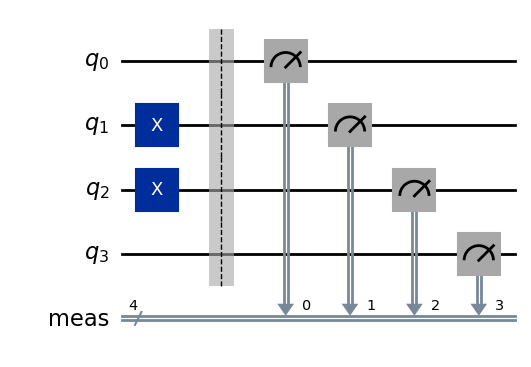

In [ ]:
# Step 1: Map

qubits = 4
N = 2**qubits


qc = QuantumCircuit(qubits)

# flip state of random qubits to put in a random single computational basis state
for i in range(1, qubits):
    if np.random.randint(0, 2):
        qc.x(i)


# make a copy of the above circuit. (to be used when we apply the QFT in next part)
qc_qft = qc.copy()


qc.measure_all()
qc.draw("mpl")

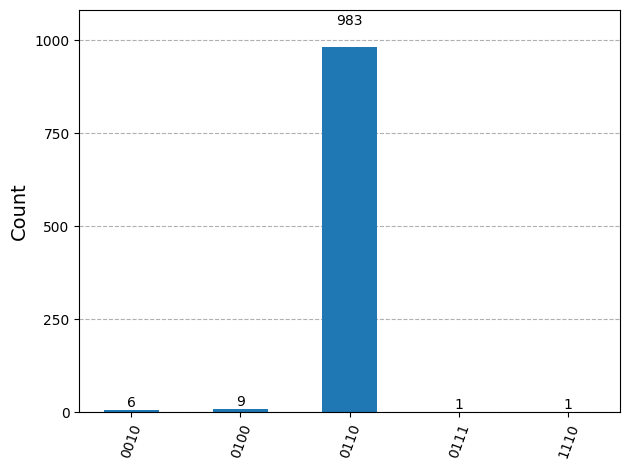

In [ ]:
# Step 2: Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

qc_isa = pm.run(qc)

# Step 3: Run the job on a real quantum computer OR try fake backend

sampler = Sampler(mode=backend)
pubs = [qc_isa]

# Run the job on real quantum device

job = sampler.run(pubs, shots=1000)
res = job.result()
counts = res[0].data.meas.get_counts()

# OR Run the job on the Aer simulator with noise model from real backend

# job = sampler_sim.run([qc_isa])
# res = job.result()
# counts = res[0].data.meas.get_counts()

# Step 4: Post-Process
plot_histogram(counts)

Now, let's Fourier transform this state with `QFTGate`:



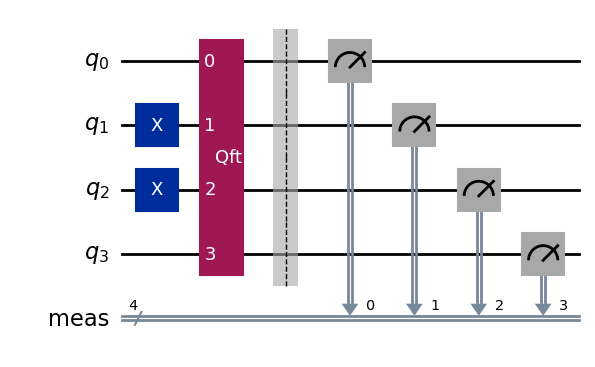

In [ ]:
# Step 1: Map

qc_qft.compose(QFTGate(qubits), inplace=True)
qc_qft.measure_all()
qc_qft.draw("mpl")

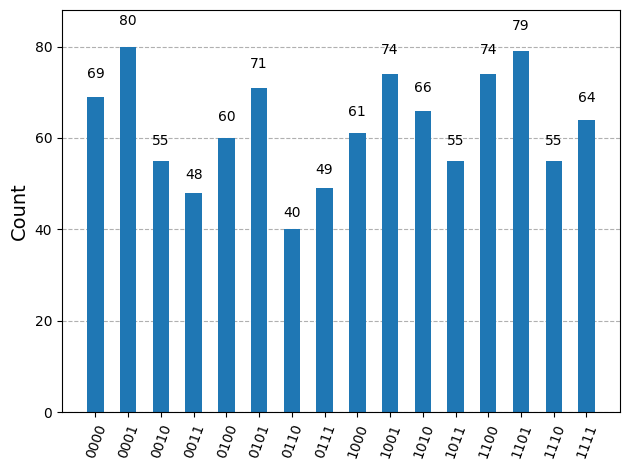

In [ ]:
# Step 2: Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

qc_isa = pm.run(qc_qft)

# Step 3: Run the job on a real quantum computer - try fake backend

sampler = Sampler(mode=backend)
pubs = [qc_isa]

# Run the job on real quantum device

job = sampler.run(pubs, shots=1000)
res = job.result()
counts = res[0].data.meas.get_counts()

# OR Run the job on the Aer simulator with noise model from real backend

# job = sampler_sim.run([qc_isa])
# res = job.result()
# counts = res[0].data.meas.get_counts()

# Step 4: Post-Process
plot_histogram(counts)

As you can see, we measure the populations of each state to be more or less equal, give or take some experimental and statistical noise. So, if you take the QFT of a single computational basis state, the result is an equal superposition of all states. If you're familiar with Fourier transforms, this probably doesn't surprise you. One basic principle that can help us build an intuitive connection between a function and its Fourier transform is that the width of a function is inversely proportional to the width of its Fourier transform. So, something that is very localized in time, for example, like a very short pulse, will require a broad range of frequencies to generate that pulse. That signal will be very broad in Fourier space.

This fact is actually related to quantum uncertainty! Heisenberg's uncertainty principle is typically stated as $\Delta x \Delta p \ge \hbar / 2 $. So if the uncertainty in $x$ ($\Delta x$) is small, the uncertainty in momentum ($\Delta p$) must be big, and vice versa. It turns out that transforming from the position basis $x$ to the momentum basis $p$ is accomplished through a Fourier transform.

Note: Keep in mind, we're measuring populations in each of the basis states, so we're losing information about the relative phases between the various parts of the superposition. So, while the QFT of any single computational basis state will yield the same even spread in population over all the basis states, the *phases* won't necessarily be the same.

#### Two computational basis states

Now, let's see what happens when we prepare a superposition of computational basis states. What do you think the Fourier transform will look like in this case?

Let's choose the superposition:

$|\psi\rangle = \frac{1}{\sqrt{2}} (|0\rangle + |N/2\rangle) = \frac{1}{\sqrt{2}} (|000...0\rangle + |100...0\rangle)$



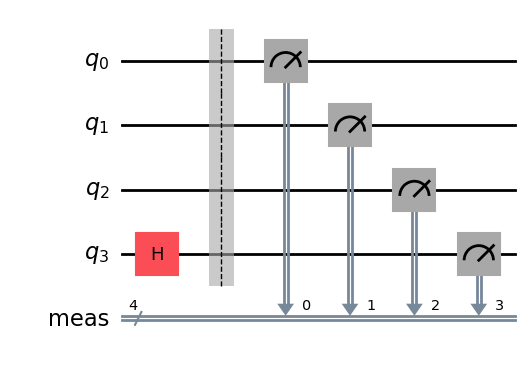

In [ ]:
# Step 1: Map
qubits = 4
N = 2**qubits


qc = QuantumCircuit(qubits)

# To make this state, we just need to apply a Hadamard to the last qubit

#qc.x(qubits - 1)    # additional modification for for peaks on every odd number
qc.h(qubits - 1)


qc_qft = qc.copy()


qc.measure_all()

qc.draw("mpl")

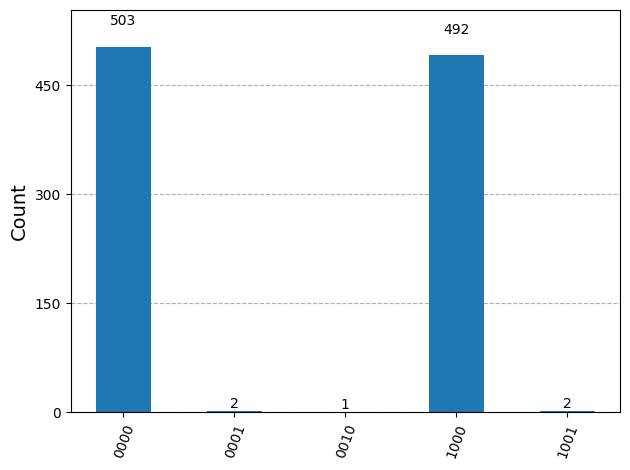

In [ ]:
# First, let's go through steps 2-4 for the first circuit, qc

# Step 2: Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

qc_isa = pm.run(qc)

# Step 3: Run the job on a real quantum computer - try fake backend

sampler = Sampler(mode=backend)
pubs = [qc_isa]

# Run the job on real quantum device

job = sampler.run(pubs, shots=1000)
res = job.result()
counts = res[0].data.meas.get_counts()

# OR run the job on the Aer simulator with noise model from real backend

# job = sampler_sim.run([qc_isa])
# res = job.result()
# counts = res[0].data.meas.get_counts()

# Step 4: Post-process
plot_histogram(counts)

Now, let's Fourier transform this state with `QFTGate`:



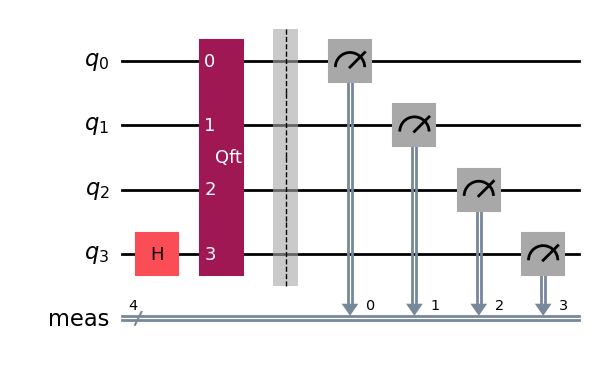

In [ ]:
# Step 1: Map

qc_qft.compose(QFTGate(qubits), inplace=True)
qc_qft.measure_all()
qc_qft.draw("mpl")

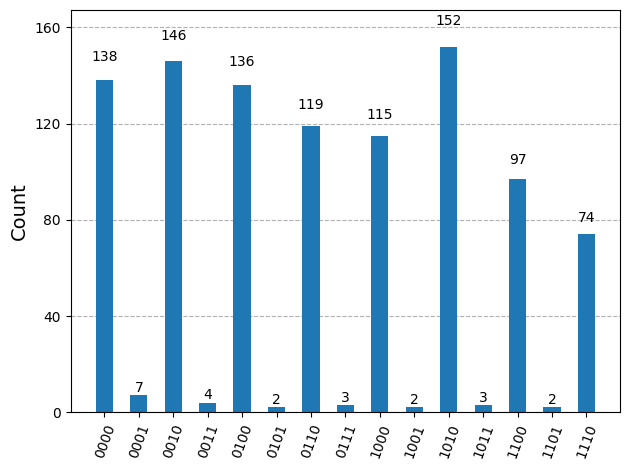

In [ ]:
# Step 2: Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

qc_isa = pm.run(qc_qft)

# Step 3: Run the job on a real quantum computer OR try fake backend

sampler = Sampler(mode=backend)
pubs = [qc_isa]

# Run the job on real quantum device

job = sampler.run(pubs, shots=1000)
res = job.result()
counts = res[0].data.meas.get_counts()

# OR run the job on the Aer simulator with noise model from real backend

# job = sampler_sim.run([qc_isa])
# res = job.result()
# counts = res[0].data.meas.get_counts()

# Step 4: Post-process
plot_histogram(counts)

This one might be a bit more surprising. It looks like the QFT of the state $|\psi\rangle = \frac{1}{\sqrt{2}} (|0\rangle + |N/2\rangle)$ is a superposition of all of the even basis states. But if we think back to our visualization of each basis state $|\phi_y\rangle$, and how the phase of each component winds around $2\pi$ $y$ times, then the reason we get this result might become clear.

#### Check your understanding

Read the question(s) below, think about your answer, then click the triangle to reveal the solution.

<details>
  <summary>
    Using the hint above, explain why the result we got for the QFT of $|\psi\rangle = \frac{1}{\sqrt{2}} (|0\rangle + |N/2\rangle)$ is expected.
  </summary>

  **Answer:**

  The original state has a relative phase of 0 (or an integer multiple of $2\pi$) between the two parts of the superposition. So, we know this state has Fourier components whose phases also match up in that way: the ones that have 0 phase shift between the |0000> term and the |1000> term. Each Fourier basis state $|\phi_y\rangle$ is composed of terms whose phase accumulates at a rate of $2\pi y/N$, meaning, when ordered in the usual way, each term in the superposition has a phase of $2\pi y/N$ greater than the term that came before. So, at the halfway point $N/2$, we want the phase $2\pi y/N * N/2$ to be an integer multiple of $2\pi$. This happens when $y$ is even.
</details>

<details>
  <summary>
    What computational state superposition would correspond to a QFT with peaks on every odd binary number?
  </summary>

  **Answer:**

  If you took the QFT of the state $\psi = |0\rangle - |N/2\rangle$, then you would see peaks on every odd binary numbered state.
</details>



## Break down the QFT algorithm

Now that we've gained more intuition into the relationship between qubit states in the computational basis and the Fourier basis, let's dig into the QFT algorithm itself. In other words, what gates do we actually implement on the quantum computer to achieve this transform?

Let's start small, with a single qubit. So, that means we'll have two basis states. QFT$_2$ transforms computational basis states $|0\rangle$ and $|1\rangle$ into Fourier basis states $\phi_0$ and $\phi_1$:

The general QFT formula is:

  $ | \phi_y \rangle =  \frac{1}{\sqrt{N}}\sum_{x=0}^{N-1}\omega_N^{y x} \vert x \rangle$

  For a single qubit ($n=1$), $N=2^n=2$, and $\omega_N^{xy} = e^{2\pi i \frac {y x}{2}}$. So, we have

  $ | \phi_0 \rangle = \frac{1}{\sqrt{2}}(e^{2\pi i \frac {0 \times 0}{2}}|0\rangle + e^{2\pi i \frac {0 \times 1}{2}}|1\rangle) = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$

  $ | \phi_1 \rangle = \frac{1}{\sqrt{2}}(e^{2\pi i \frac {1 \times 0}{2}}|0\rangle + e^{2\pi i \frac {1 \times 1}{2}}|1\rangle) = \frac{1}{\sqrt{2}}(|0\rangle - |1\rangle)$

It's a Hadamard gate! that can be used to implement this transform. That is, there is a gate that transforms the computational basis states $|0\rangle$ and $|1\rangle$ to the respective Fourier basis states $|\phi_0\rangle$ and $|\phi_1\rangle$.  This becomes even more clear if we introduce a matrix representation of the QFT$_N$ operation:

$ \text{QFT}_N = \frac{1}{\sqrt{N}} \sum_{x=0}^{N-1} \sum_{y=0}^{N-1} \omega_N^{xy} \vert x \rangle \langle y \vert$

Lets try to construct the matrix for QFT$_4$. Using the above formula, we find that

$\text{QFT}_4 = \frac{1}{2}
\begin{pmatrix}
    1 & 1 & 1 & 1 \\
    1 & i & -1 & -i \\
    1 & -1 & 1 & -1 \\
    1 & -i & -1 & i \\
\end{pmatrix}
$

To implement this matrix on a quantum computer, 

we'll need to figure out which combination of gates applied to which qubits will give us a unitary transformation that matches the matrix above. 

- We already know one of the gates that will be needed: the Hadamard. 

- Another gate we'll need is the controlled-phase gate, which applies a relative phase $\alpha$ to the target qubit's state, as long as the control qubit is in the state $|1\rangle$. In matrix form this looks like:

$\text{CP}_\alpha =
\begin{pmatrix}
    1 & 0 & 0 & 0 \\
    0 & 1 & 0 & 0 \\
    0 & 0 & 1 & 0 \\
    0 & 0 & 0 & e^{i\alpha} \\
\end{pmatrix}
$

Since only the state $|11\rangle$ is changed, it actually doesn't matter which qubit is considered the "control" and which is the "target." The result will be the same either way.

Finally, we'll need some SWAP gates too. A SWAP gate swaps the states of two qubits. It looks like:

$\text{SWAP}_\alpha =
\begin{pmatrix}
    1 & 0 & 0 & 0 \\
    0 & 0 & 1 & 0 \\
    0 & 1 & 0 & 0 \\
    0 & 0 & 0 & 1 \\
\end{pmatrix}
$

The procedure to construct a QFT$_{2^m}$ circuit on $m$ qubits is iterative — you first apply QFT$_{2^{m-1}}$ to qubits $1$ through $m-1$, then add some gates between qubit $0$ and the other $m-1$ qubits. But to apply QFT$_{2^{m-1}}$, you first need to apply QFT$_{2^{m-2}}$ to qubits 2 through $m-1$, then add some gates between qubit 1 and the remaining qubits $2$ through $m-1$. It's like a Russian nesting doll: each doll adds a factor of two in the dimension of the QFT circuit, with the smallest doll at the very center, being QFT$_2$, or the Hadamard gate.

To put a doll inside the next biggest size doll, hence increasing the dimension of the QFT by a factor of two, you always follow the same procedure:

1.  First, apply QFT$_{2^{m-1}}$ to the bottom-most $m-1$ qubits. This is your "smaller doll" of the Russian nesting doll set that you will soon put inside the next-biggest doll.
2.  Use the next qubit up as a control, and apply controlled phase gates to each of the bottom $m-1$ qubits, with phases to the standard basis states of each of the remaining $m-1$ qubits.
3.  Perform a Hadamard on that same top-most qubit that was used as the control in the phase gates.
4.  Use SWAP gates to permute the order of the qubits so that the least significant (top) bit becomes the most significant (bottom) bit, and all others shift up by one.

We've already been using the `QFTGate` function from the Qiskit circuit library, but now let's take a look inside of some of these QFT gates to verify the above procedure. We can do this with `decompose()`.



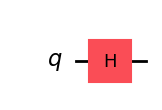

In [ ]:
qc = QuantumCircuit(1)
qc.compose(QFTGate(1), inplace=True)
qc.decompose().draw("mpl")

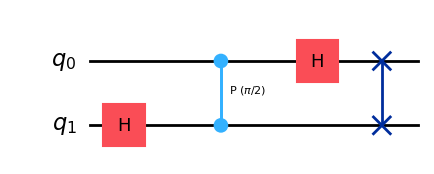

In [ ]:
qc = QuantumCircuit(2)
qc.compose(QFTGate(2), inplace=True)
qc.decompose().draw("mpl")

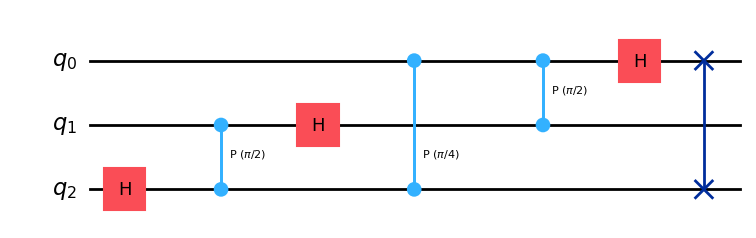

In [ ]:
qc = QuantumCircuit(3)
qc.compose(QFTGate(3), inplace=True)
qc.decompose().draw("mpl")

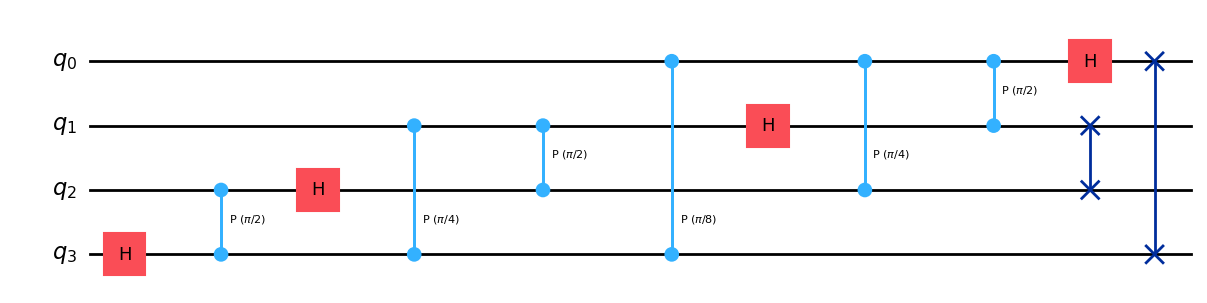

In [ ]:
qc = QuantumCircuit(4)
qc.compose(QFTGate(4), inplace=True)
qc.decompose().draw("mpl")

### Critical concepts

*   The Quantum Fourier Transform is the quantum analog to the Discrete Fourier Transform.
*   The QFT is an example of a basis transformation.
*   The Quantum Phase Estimation procedure relies on the phase-kickback mechanism from the controlled-unitary operations, as well as an inverse QFT.
*   QFT and QPE are both widely used subroutines in numerous quantum algorithms.

## Questions

### True/False

1.  T/F The Quantum Fourier Transform is the quantum analog of the classical discrete Fourier transform (DFT).
2.  T/F QFT can be implemented using only Hadamard and CNOT gates.
3.  T/F QFT is a key component of Shor’s algorithm.
4.  T/F The output of Quantum Phase Estimation is a quantum state representing the eigenvector of the operator.
5.  T/F QPE requires the use of the inverse Quantum Fourier Transform (QFT$^\dag$).
6.  T/F In QPE, if the phase $\phi$ is exactly representable with $n$ bits, the algorithm gives the correct result with probability 1.

### Short answers

1.  How many qubits are needed to perform a QFT on a system with $2^n$ data points?
2.  Can the QFT be used on a state that is not a computational basis state? If so, what happens?
3.  How does the number of control qubits used in QPE affect the resolution of the resulting phase estimate?

### Problems

1.  Use matrix multiplication to verify that the steps in the QFT algorithm indeed result in the $\text{QFT}_4$ matrix:

$$
\text{QFT}_4 = \frac{1}{2}
\begin{pmatrix}
    1 & 1 & 1 & 1 \\
    1 & i & -1 & -i \\
    1 & -1 & 1 & -1 \\
    1 & -i & -1 & i \\
\end{pmatrix}
$$

(You don't have to do this by hand!)

### Challenge problems

1.  Make a four-qubit state that is an equal superposition of all odd computational bases: $|\psi\rangle = |0001\rangle + |0011\rangle + |0101\rangle + |0111\rangle +|1001\rangle +|1011\rangle +|1101\rangle +|1111\rangle$. Then perform a QFT on the state. What is the resulting state? Explain why your result makes sense, using your knowledge of Fourier transforms.

